# Cybersecurity anomaly detection: a guided experiment

This notebook connects the reusable code in **src/** into one experiment that you can read from top to bottom.

**The question:** can a four-qubit model give attack traffic higher scores than normal traffic, and how does that change as we add layers?

We train using **normal traffic only**. Attack labels are used for evaluation, not for updating the circuit's weights. The default experiment runs entirely on your computer using an ideal quantum simulation. IBM connection and job submission are separate, disabled options near the end.

No old notebook results are copied into this notebook. A number printed here will come from the run you actually execute.

**Before running:** select your project's **.venv** as the notebook kernel and set the CSV path in Section 2. Read Sections 1–12 as our first architecture checkpoint. Hardware work is optional and comes afterward.

Run cells in order. Restarting the kernel clears Python variables; the saved run files preserve results, but they do not automatically restore the notebook's state.

## The route through the experiment

| Step | What happens | Main module |
|---|---|---|
| Prepare data | Split the rows, learn preprocessing from normal training rows, produce four angles | data.py |
| Build the model | Encode those angles once, then apply adjustable circuit layers | workload.py |
| Train | Add one layer at a time and keep earlier weights fixed | workload.py |
| Score and evaluate | Compare normal and attack scores on the same validation rows at every depth | workload.py + evaluation.py |
| Save and explain | Save weights, sample identities, preprocessing, tables, and figures | This notebook |
| Optional hardware | Run the frozen models on IBM hardware and compare with ideal scores | backend.py + execution.py + workload.py |
| Optional controller | Use fresh MRB measurements to restrict the deployment choices | probes.py + controller.py |

A **depth** here is the number of model layers, L=1…5. It is not the same as a circuit's compiled gate depth or an MRB benchmark depth.

## 1. Import the reusable code

The next cell locates the repository whether Jupyter starts in the project folder or in **notebooks/**. It does not change the working directory.

Importing the modules does not read credentials or contact IBM. The actual algorithms remain in Python modules; the notebook controls their order and explains the results.

In [14]:
import sys
import json
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
from uuid import uuid4

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve

# Look only in the current folder and its parents for this repository.
REPO_ROOT = next(
    (folder for folder in [Path.cwd(), *Path.cwd().parents]
     if (folder / "src" / "workload.py").is_file()
     and (folder / "requirements.txt").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from inside the project repository.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import data, workload, evaluation, backend, execution, probes, controller

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Repository:", REPO_ROOT)
print("Python kernel:", sys.executable)

Repository: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa
Python kernel: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\.venv\Scripts\python.exe


## 2. Choose the run settings

These defaults match the latest teammate experiment: 2,000 normal examples form the QML pool, 128 of them form the fixed local training set, and each layer gets 100 SPSA steps.

The larger local validation set has **32 normal + 32 attack** rows. The smaller hardware comparison has **16 + 16**, matching the latest notebook's final hardware workload. They are two different selections; we will calculate an ideal reference on exactly the hardware selection before comparing it with IBM results.

A **seed** makes a random selection repeatable. Changing a seed, the CSV row order, or a preprocessing rule can change the experiment.

By default:
- Run the local experiment and save its artifacts.
- Do not evaluate the held-out test set.
- Do not connect to IBM or submit jobs.

A small iteration count is useful for checking that the workflow runs, but record it honestly: it is a different training run, not the teammate's 100-step experiment.

In [15]:
CSV_PATH = REPO_ROOT / "data" / "raw" / "UNSW_NB15_training-set.csv"
MODEL_CHECKPOINT = None  # Or an explicit path to compatible weights with keys L1...L5.
SAVE_RESULTS = True

DEPTHS = list(workload.DEPTHS)
SPLIT_SEED = 42
QML_POOL_SIZE = 2000
LOCAL_TRAIN_SIZE = 128
LOCAL_TRAIN_SEED = 2026
TRAINING_SEED = 42
SPSA_ITERATIONS = 100
SPSA_A = 0.10  # Controls the size of weight updates.
SPSA_C = 0.08  # Controls the size of the two temporary perturbations.
CHECK_EVERY = 5

VALIDATION_PER_CLASS = 32
VALIDATION_SEED = 123
HARDWARE_PER_CLASS = 16
HARDWARE_SAMPLE_SEED = 777
BOOTSTRAP_REPEATS = 5000
BOOTSTRAP_SEED = 42
CONFIDENCE = 0.95
TARGET_VALIDATION_FALSE_ALARM_RATE = 0.05

# Keep test rows for a final check after the model/architecture choices are fixed.
RUN_HELD_OUT_TEST = False
TEST_SAMPLE_SIZE = 1024
TEST_SEED = 2027

# These are independent, deliberate actions. Both stay False for normal local runs.
CONNECT_TO_IBM = False
SUBMIT_QPU_JOBS = False
BACKEND_NAME = "ibm_quebec"
HARDWARE_REGIONS = {name: qubits.copy() for name, qubits in backend.REGIONS.items()}
SHOTS = 256

# Optional later input from a fresh, single MRB run on the same backend.
MRB_RESULTS_PATH = None
MAX_POLARIZATION_LOSS = None  # Choose an explicit budget before applying the controller.

if SUBMIT_QPU_JOBS and not CONNECT_TO_IBM:
    raise ValueError("QPU submission requires CONNECT_TO_IBM=True.")
if SUBMIT_QPU_JOBS and not SAVE_RESULTS:
    raise ValueError("Enable SAVE_RESULTS so hardware job IDs and results can be preserved.")

# Merely defining these paths does not create files.
run_name = datetime.now(timezone.utc).strftime("unsw_nested_%Y%m%dT%H%M%SZ_") + uuid4().hex[:8]
RUN_DIR = REPO_ROOT / "results" / run_name if SAVE_RESULTS else None
FIGURE_DIR = RUN_DIR / "figures" if RUN_DIR is not None else None

print("Model depths:", DEPTHS)
print("Local training steps per depth:", SPSA_ITERATIONS)
print("IBM connection enabled:", CONNECT_TO_IBM)
print("QPU submission enabled:", SUBMIT_QPU_JOBS)

Model depths: [1, 2, 3, 4, 5]
Local training steps per depth: 100
IBM connection enabled: False
QPU submission enabled: False


## 3. Load UNSW-NB15 and understand the labels

Each CSV row describes a network flow. A label of **0 means normal** and **1 means attack**.

The loader removes:
- **id**, which identifies a row rather than describing traffic;
- **label**, which is the answer we want to predict;
- **attack_cat**, which reveals the attack category and would leak the answer into the model.

We use an internal train/validation/test split of this one CSV. Its official filename does not determine our experimental split. The CSV is not bundled with this repository: point CSV_PATH at your local copy if necessary.

In [16]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"UNSW CSV not found: {CSV_PATH}. Set CSV_PATH to your local dataset."
    )

X_raw, y = data.load_unsw(CSV_PATH)

# A file fingerprint identifies the exact input, including its row order.
with CSV_PATH.open("rb") as handle:
    dataset_sha256 = hashlib.file_digest(handle, "sha256").hexdigest()

display(pd.DataFrame({
    "class": ["normal", "attack"],
    "rows": [int(np.sum(y == 0)), int(np.sum(y == 1))],
}))
print("Rows:", len(y), "| Input features after removing answer columns:", X_raw.shape[1])
print("Attack proportion in this CSV:", f"{y.mean():.2%}")

,class,rows
0,normal,56000
1,attack,119341


Rows: 175341 | Input features after removing answer columns: 42
Attack proportion in this CSV: 68.06%


## 4. Turn the raw features into four circuit inputs

The preparation function performs these steps, in order:

1. **Split 70/15/15.** Training rows teach the model; validation rows guide comparisons; test rows remain for a final check. The split preserves each class's proportion approximately.
2. **Use all normal training rows to fit preprocessing.** This is separate from the later 2,000-row QML sample. Neither validation nor test rows teach the scalers or compression.
3. **Standardize numeric features.** Subtract their normal-training means and divide by their normal-training standard deviations.
4. **One-hot encode categories.** A category such as a protocol becomes a set of 0/1 indicator columns. Unseen categories do not cause a crash.
5. **Compress to four numbers with TruncatedSVD.** This finds four directions that preserve some variation in the encoded data. It works with the sparse category representation, where most entries are zero.
6. **Standardize the four components, clip to ±3, and multiply by π/3.** This produces four rotation angles in [-π, π].
7. **Only then sample 2,000 normals** for the QML pool.

SVD's reported **variance captured** describes information retained in the preprocessing space. It is not classification accuracy. Four components discard information, so this remains a modeling choice to evaluate.

The test features are transformed with already fitted preprocessing, but their detection scores are not evaluated in the default run.

In [17]:
prepared = data.prepare_unsw(X_raw, y, n_train=QML_POOL_SIZE, seed=SPLIT_SEED)

split_rows = []
for split in ["train", "val", "test"]:
    indices = prepared[f"{split}_idx"]
    split_rows.append({
        "split": split,
        "rows": len(indices),
        "normal": int(np.sum(y[indices] == 0)),
        "attack": int(np.sum(y[indices] == 1)),
    })
display(pd.DataFrame(split_rows))

print("Normal rows used to fit preprocessing:", prepared["metadata"]["preprocessing_fit_rows"])
print("Normal rows in the QML pool:", len(prepared["X_train_q"]))
print("Categorical columns:", prepared["metadata"]["categorical_columns"])
print("Numeric column count:", len(prepared["metadata"]["numeric_columns"]))
print("Variance captured by four SVD components:", f'{prepared["metadata"]["variance_captured"]:.2%}')
print("Training angle range:", prepared["X_train_q"].min(), prepared["X_train_q"].max())
assert np.all(prepared["y_train"] == 0)

,split,rows,normal,attack
0,train,122738,39200,83538
1,val,26301,8400,17901
2,test,26302,8400,17902


Normal rows used to fit preprocessing: 39200
Normal rows in the QML pool: 2000
Categorical columns: ['proto', 'service', 'state']
Numeric column count: 39
Variance captured by four SVD components: 47.89%
Training angle range: -3.141592653589793 3.141592653589793


## 5. Fix the samples before comparing models

We select the same **128 normal rows** for every training-loss calculation. This removes changing minibatches as a source of loss variation during local debugging.

We also select validation rows once and reuse them at every depth and region. Otherwise, a depth comparison could accidentally become a comparison of different traffic samples.

**sample_id** means a row's position in the original CSV, starting at zero. It is not the removed id feature. Keeping these identities lets the paired bootstrap match the same traffic rows across results.

Balanced validation makes depth comparisons manageable, but its 50% attack proportion differs from the full CSV. Precision, F1, and average precision depend on this class mix.

In [18]:
local_training = data.select_local_training(
    prepared, size=LOCAL_TRAIN_SIZE, seed=LOCAL_TRAIN_SEED
)
X_local_train = local_training["X_train_q"]

validation_indices = data.select_validation_samples(
    prepared["y_val"], n_per_class=VALIDATION_PER_CLASS, seed=VALIDATION_SEED
)
X_eval = prepared["X_val_q"][validation_indices]
y_eval = prepared["y_val"][validation_indices]
validation_sample_ids = prepared["val_idx"][validation_indices]

hardware_indices = data.select_validation_samples(
    prepared["y_val"], n_per_class=HARDWARE_PER_CLASS, seed=HARDWARE_SAMPLE_SEED
)
X_hardware_eval = prepared["X_val_q"][hardware_indices]
y_hardware_eval = prepared["y_val"][hardware_indices]
hardware_sample_ids = prepared["val_idx"][hardware_indices]

assert set(local_training["sample_ids"]).isdisjoint(validation_sample_ids)
assert set(local_training["sample_ids"]).isdisjoint(hardware_sample_ids)
print("Fixed local training shape:", X_local_train.shape)
print("Local validation shape:", X_eval.shape)
print("Hardware comparison shape:", X_hardware_eval.shape)

Fixed local training shape: (128, 4)
Local validation shape: (64, 4)
Hardware comparison shape: (32, 4)


## 6. Create a record of this run

The following cell writes files only when SAVE_RESULTS=True. It creates a new, uniquely named directory under **results/** rather than replacing a previous experiment.

We save the exact input fingerprint, settings, software versions, fitted preprocessing, split indices, and chosen angles. This preserves what produced the results; a theta vector alone is not enough to reproduce a detector.

The small helpers below only write run records and figures. They are notebook orchestration, not copies of the model or statistical algorithms.

In [19]:
software_versions = {
    package: version(package)
    for package in ["numpy", "pandas", "scikit-learn", "scipy", "qiskit",
                    "qiskit-ibm-runtime", "matplotlib", "joblib"]
}
config = {
    "run_name": run_name,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "software_versions": software_versions,
    "dataset": {"path": str(CSV_PATH), "sha256": dataset_sha256,
                "rows": len(y), "features": X_raw.shape[1]},
    "preprocessing": prepared["metadata"],
    "architecture": {"name": "unsw_nested_ry_rz_crx", "qubits": 4,
                     "encoding": "four_Ry_once", "parameters_per_layer": 11,
                     "depths": DEPTHS, "anomaly_score": "1-P(0000)"},
    "training": {"performed_here": MODEL_CHECKPOINT is None,
                 "checkpoint": None if MODEL_CHECKPOINT is None else str(MODEL_CHECKPOINT),
                 "normal_pool_size": QML_POOL_SIZE, "local_size": LOCAL_TRAIN_SIZE,
                 "local_seed": LOCAL_TRAIN_SEED, "seed": TRAINING_SEED,
                 "iterations": SPSA_ITERATIONS, "a": SPSA_A, "c": SPSA_C,
                 "check_every": CHECK_EVERY},
    "validation": {"per_class": VALIDATION_PER_CLASS, "seed": VALIDATION_SEED,
                   "bootstrap_repeats": BOOTSTRAP_REPEATS,
                   "confidence": CONFIDENCE, "bootstrap_seed": BOOTSTRAP_SEED},
    "hardware": {"backend": BACKEND_NAME, "regions": HARDWARE_REGIONS, "shots": SHOTS,
                 "per_class": HARDWARE_PER_CLASS, "sample_seed": HARDWARE_SAMPLE_SEED,
                 "connect_enabled": CONNECT_TO_IBM, "submit_enabled": SUBMIT_QPU_JOBS},
    "threshold": {"rule": "normal_validation_quantile",
                  "target_false_alarm_rate": TARGET_VALIDATION_FALSE_ALARM_RATE},
    "held_out_test": {"enabled": RUN_HELD_OUT_TEST, "sample_size": TEST_SAMPLE_SIZE,
                      "seed": TEST_SEED},
}

def json_value(value):
    # Convert NumPy values to ordinary numbers/lists for readable JSON files.
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Cannot save this type as JSON: {type(value).__name__}")

def save_json(filename, content):
    if RUN_DIR is not None:
        with (RUN_DIR / filename).open("w", encoding="utf-8") as handle:
            json.dump(content, handle, indent=2, allow_nan=False, default=json_value)

def save_figure(figure, name):
    if FIGURE_DIR is not None:
        figure.savefig(FIGURE_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
        figure.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

if RUN_DIR is not None:
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    FIGURE_DIR.mkdir()
    save_json("config.json", config)
    joblib.dump(prepared["preprocessor"], RUN_DIR / "preprocessor.joblib")
    np.savez_compressed(
        RUN_DIR / "prepared_samples.npz",
        train_idx=prepared["train_idx"], val_idx=prepared["val_idx"],
        test_idx=prepared["test_idx"], normal_train_idx=prepared["normal_train_idx"],
        qml_train_idx=prepared["qml_train_idx"], qml_choice=prepared["qml_choice"],
        X_train_q=prepared["X_train_q"], y_train=prepared["y_train"],
        X_val_q=prepared["X_val_q"], y_val=prepared["y_val"],
        X_test_q=prepared["X_test_q"], y_test=prepared["y_test"],
        local_pool_indices=local_training["pool_indices"],
        local_sample_ids=local_training["sample_ids"], X_local_train=X_local_train,
        validation_indices=validation_indices, validation_sample_ids=validation_sample_ids,
        X_eval=X_eval, y_eval=y_eval,
        hardware_indices=hardware_indices, hardware_sample_ids=hardware_sample_ids,
        X_hardware_eval=X_hardware_eval, y_hardware_eval=y_hardware_eval,
    )
    print("Saving this run to:", RUN_DIR)
else:
    print("Saving disabled. Results exist only in this kernel.")

Saving this run to: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\unsw_nested_20261008T025411Z_a86f5fa1


## 7. Understand the circuit before training it

The circuit starts with four **Ry rotations**, one for each data angle. A rotation is a quantum operation whose angle controls how it changes a qubit's state. This input step is mandatory and happens once.

Each added layer has:
- **Eight adjustable rotations:** Ry and Rz on each of the four qubits.
- **Three adjustable CRX gates:** 0→1, 1→2, and 2→3. A CRX rotates the target qubit around its X axis, controlled by the neighboring qubit.

That gives **11 weights per layer**, or 11/22/33/44/55 weights for L1–L5. The latest implementation uses **CRX**, although some old notebook comments say RZZ.

When all eleven weights in a new layer are zero, that layer does nothing mathematically. Therefore adding eleven zeros to an L1 model initially gives the same ideal model at L2. This is what **nested** means here.

The four data angles and the trainable weights are separate parameters. There is no adjustable input-strength gate that can simply switch the data off.

In [20]:
parameter_counts = []
for L in DEPTHS:
    circuit, feature_parameters, theta_parameters = workload.build_unsw_nested_circuit(L)
    parameter_counts.append({
        "L": L, "input_angles": len(feature_parameters),
        "trainable_weights": len(theta_parameters),
    })
display(pd.DataFrame(parameter_counts))

example_circuit, _, _ = workload.build_unsw_nested_circuit(1)
display(example_circuit.draw(output="text", fold=100))

,L,input_angles,trainable_weights
0,1,4,11
1,2,4,22
2,3,4,33
3,4,4,44
4,5,4,55


┌──────────┐ ░ ┌──────────────┐┌──────────────┐                                »
q_0: ┤ Ry(x[0]) ├─░─┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├───────■────────────────────────»
     ├──────────┤ ░ ├──────────────┤├──────────────┤┌──────┴───────┐                »
q_1: ┤ Ry(x[1]) ├─░─┤ Ry(theta[2]) ├┤ Rz(theta[3]) ├┤ Rx(theta[8]) ├───────■────────»
     ├──────────┤ ░ ├──────────────┤├──────────────┤└──────────────┘┌──────┴───────┐»
q_2: ┤ Ry(x[2]) ├─░─┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├────────────────┤ Rx(theta[9]) ├»
     ├──────────┤ ░ ├──────────────┤├──────────────┤                └──────────────┘»
q_3: ┤ Ry(x[3]) ├─░─┤ Ry(theta[6]) ├┤ Rz(theta[7]) ├────────────────────────────────»
     └──────────┘ ░ └──────────────┘└──────────────┘                                »
«                       ░ 
«q_0: ──────────────────░─
«                       ░ 
«q_1: ──────────────────░─
«                       ░ 
«q_2: ────────■─────────░─
«     ┌───────┴───────┐ ░ 
«q_3: ┤ Rx(theta[10]) ├─░─
«     └───────────────┘ ░

### What the detector returns

After running the circuit, imagine measuring all four qubits. Our anomaly score is:

**A(x) = 1 − P(0000)**

P(0000) is the probability that all four measured bits are zero. A low score means the circuit is likely to return 0000; a high score means it is less likely.

Training asks normal traffic to have low scores. It does not explicitly push attack scores upward, because attacks are excluded from training. Evaluation must tell us whether attacks actually score higher.

The score lies between 0 and 1, but it is **not a calibrated probability that a network flow is an attack**.

A **Statevector** calculation computes the circuit's ideal quantum state exactly on this computer. It contains no hardware noise and no random sampling of measurement shots. Later, hardware will estimate the same score from finite measurement counts.

### Check that a zero-initialized layer really preserves the model

This is a small numerical check before training, not a claim about detection quality. We compare L with L+1 using the same data and append eleven zeros to the weights.

The score differences should be zero apart from floating-point rounding. The guarantee concerns the ideal circuit: after compilation, additional layers can still carry hardware gate costs.

In [21]:
identity_rng = np.random.default_rng(123)
nesting_checks = []
for L in DEPTHS[:-1]:
    weights = identity_rng.normal(0.0, 0.2, workload.PARAMS_PER_LAYER * L)
    extended = np.concatenate([weights, np.zeros(workload.PARAMS_PER_LAYER)])
    shallow_scores = workload.nested_scores(L, weights, X_eval[:5])
    extended_scores = workload.nested_scores(L + 1, extended, X_eval[:5])
    np.testing.assert_allclose(shallow_scores, extended_scores, rtol=0, atol=1e-12)
    nesting_checks.append({
        "comparison": f"L{L} vs L{L + 1} with an identity new layer",
        "largest_score_difference": float(np.max(np.abs(shallow_scores - extended_scores))),
    })
display(pd.DataFrame(nesting_checks))
save_json("nesting_checks.json", nesting_checks)

,comparison,largest_score_difference
0,L1 vs L2 with an identity new layer,0.0
1,L2 vs L3 with an identity new layer,0.0
2,L3 vs L4 with an identity new layer,0.0
3,L4 vs L5 with an identity new layer,0.0


## 8. Train one layer at a time, or load compatible weights

**Progressive training** means:
1. Train L1 from small random weights.
2. Keep those weights fixed.
3. Append an all-zero layer and train only its eleven new weights.
4. Repeat through L5.

We use **SPSA**: temporarily move all eleven active weights in one random direction and in the opposite direction, compare the two losses, then use that comparison to update the active weights. This avoids calculating a separate derivative for every weight.

The **loss** is the mean anomaly score of the fixed normal training samples. Every five steps we calculate the actual score at the current weights and keep the best checked weights, including the starting weights. These are center losses, not averages of the two temporary perturbations.

Lower training loss does not guarantee higher validation AUC. New layers preserve the earlier function only at their zero initialization; training them can still harm detection of unseen traffic.

With 128 samples, 100 steps, and five depths, exact local training may take several minutes or longer. The callback saves completed depths and prints progress.

**Loading instead:** MODEL_CHECKPOINT must contain L1…L5 arrays from this same circuit and score definition. It must also belong to the same preprocessing, data, and sampling setup. Weight lengths alone cannot prove that compatibility. This branch rebuilds preprocessing above; it does not restore someone else's scaler/SVD automatically. A weights-only handoff without its preprocessing record cannot establish reproducibility.

In [22]:
models = {}
histories = {}
completed_models = {}

def record_finished_depth(L, theta, history):
    # This callback records completed depths; it does not perform optimization.
    completed_models[L] = theta.copy()
    print(f"L{L} complete | best checked normal loss: {min(row['loss'] for row in history):.5f}")
    if RUN_DIR is not None:
        np.savez_compressed(
            RUN_DIR / "models_progress.npz",
            **{f"L{depth}": values for depth, values in completed_models.items()},
        )
        save_json(f"training_history_L{L}.json", history)

if MODEL_CHECKPOINT is None:
    models, histories = workload.train_progressive(
        X_local_train, depths=DEPTHS, iterations=SPSA_ITERATIONS,
        a=SPSA_A, c=SPSA_C, seed=TRAINING_SEED, check_every=CHECK_EVERY,
        on_depth=record_finished_depth,
    )
else:
    checkpoint_path = Path(MODEL_CHECKPOINT).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = REPO_ROOT / checkpoint_path
    with np.load(checkpoint_path, allow_pickle=False) as archive:
        for L in DEPTHS:
            key = f"L{L}"
            if key not in archive:
                raise ValueError(f"Checkpoint is missing {key}; a partial run is not a full five-depth model.")
            models[L] = np.asarray(archive[key], dtype=float).copy()
    with checkpoint_path.open("rb") as handle:
        checkpoint_sha256 = hashlib.file_digest(handle, "sha256").hexdigest()
    save_json("checkpoint_source.json", {
        "path": str(checkpoint_path), "sha256": checkpoint_sha256,
        "compatibility_note": "Weights supplied as compatible by the experiment owner.",
    })
    print("Loaded weights. Training histories are unavailable for this branch.")

# Detect wrong model sizes and ensure deeper models retain the trained prefix.
for L in DEPTHS:
    if models[L].shape != (workload.PARAMS_PER_LAYER * L,) or not np.isfinite(models[L]).all():
        raise ValueError(f"Invalid weights for L{L}.")
    if L > 1:
        np.testing.assert_allclose(models[L][:len(models[L - 1])], models[L - 1], rtol=0, atol=1e-12)

if RUN_DIR is not None:
    np.savez_compressed(RUN_DIR / "models.npz", **{f"L{L}": models[L] for L in DEPTHS})
    save_json("training_histories.json", histories)
display(pd.DataFrame({"L": DEPTHS, "saved_weights": [len(models[L]) for L in DEPTHS]}))

L1 complete | best checked normal loss: 0.42601
L2 complete | best checked normal loss: 0.41846
L3 complete | best checked normal loss: 0.41379
L4 complete | best checked normal loss: 0.41164
L5 complete | best checked normal loss: 0.41064


,L,saved_weights
0,1,11
1,2,22
2,3,33
3,4,44
4,5,55


### Read the training-loss figure carefully

The curves show the normal training loss at the checked steps. The returned model uses the lowest checked value, which may occur before the final step.

A deeper layer starts from the preceding model's function. Its own loss curve measures improvement on the normal training set. It does not measure attack detection or hardware health.

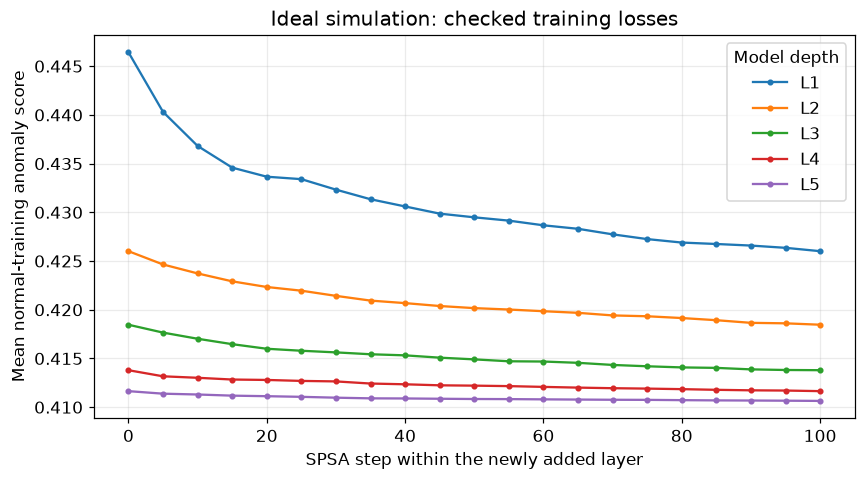

In [23]:
if histories:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for L in DEPTHS:
        history = pd.DataFrame(histories[L])
        ax.plot(history["iteration"], history["loss"], marker=".", label=f"L{L}")
    ax.set(xlabel="SPSA step within the newly added layer",
           ylabel="Mean normal-training anomaly score",
           title="Ideal simulation: checked training losses")
    ax.grid(alpha=0.25)
    ax.legend(title="Model depth")
    fig.tight_layout()
    save_figure(fig, "ideal_training_losses")
    plt.show()
else:
    print("No loss curve: these weights were loaded without training histories.")

## 9. Evaluate every depth on the same validation rows

The weights are now frozen. We pass both normal and attack validation rows through each circuit.

We save **one row per sample per depth**, including its original sample_id. The summary asks:

- **Normal mean:** do normal rows have low scores?
- **Attack mean:** do attack rows have higher scores?
- **Separation:** attack mean minus normal mean. Positive is the intended direction.
- **ROC-AUC:** how often does an attack rank above a normal row, with ties counting halfway? 1 means perfect ranking on these samples; 0.5 is chance-level ranking.
- **Average precision:** a summary of precision across increasing recall. It depends on the attack proportion in the evaluated sample.

ROC-AUC is not “the percentage of traffic classified correctly.” It measures ranking across possible score cutoffs.

Do not flip low-AUC scores after seeing validation labels without treating that as a new model choice.

In [24]:
validation_scores = []
validation_metadata = []

for L in DEPTHS:
    depth_scores = workload.nested_scores(L, models[L], X_eval)
    validation_scores.extend(depth_scores)
    validation_metadata.extend({
        "L": L, "sample_index": i, "sample_id": int(sample_id),
        "score": "1-P(0000)", "execution": "ideal_statevector",
    } for i, sample_id in enumerate(validation_sample_ids))

validation_frame = evaluation.results_to_frame(
    validation_scores, validation_metadata, y_eval, region="ideal"
)
validation_summary = evaluation.summarize_results(validation_frame)

display(validation_summary[[
    "L", "n_samples", "normal_mean", "anomaly_mean", "separation", "roc_auc", "average_precision"
]])
if RUN_DIR is not None:
    validation_frame.to_csv(RUN_DIR / "ideal_validation_scores.csv", index=False)
    validation_summary.to_csv(RUN_DIR / "ideal_validation_metrics.csv", index=False)

,L,n_samples,normal_mean,anomaly_mean,separation,roc_auc,average_precision
0,1,64,0.351902,0.754031,0.402129,0.917969,0.871719
1,2,64,0.338600,0.762417,0.423817,0.922852,0.876155
2,3,64,0.329766,0.773317,0.443550,0.921875,0.875273
3,4,64,0.324898,0.781295,0.456397,0.921875,0.875273
4,5,64,0.322050,0.786131,0.464081,0.922852,0.876297


### Two ways to view all score cutoffs

**ROC curve:** as we lower the cutoff for calling a sample an attack, plot the fraction of normal rows falsely flagged (horizontal) against the fraction of attacks detected (vertical). The diagonal is a chance-ranking reference; the ideal corner is top-left.

**Precision–recall curve:** plot the fraction of attacks detected (recall, horizontal) against the fraction of flagged rows that really are attacks (precision, vertical). A useful model stays high as recall increases.

The dashed precision baseline is the evaluated attack proportion, here 50%. A different class mix changes precision and its baseline even when score distributions stay similar. **AP** means average precision; it is not another name for ROC-AUC.

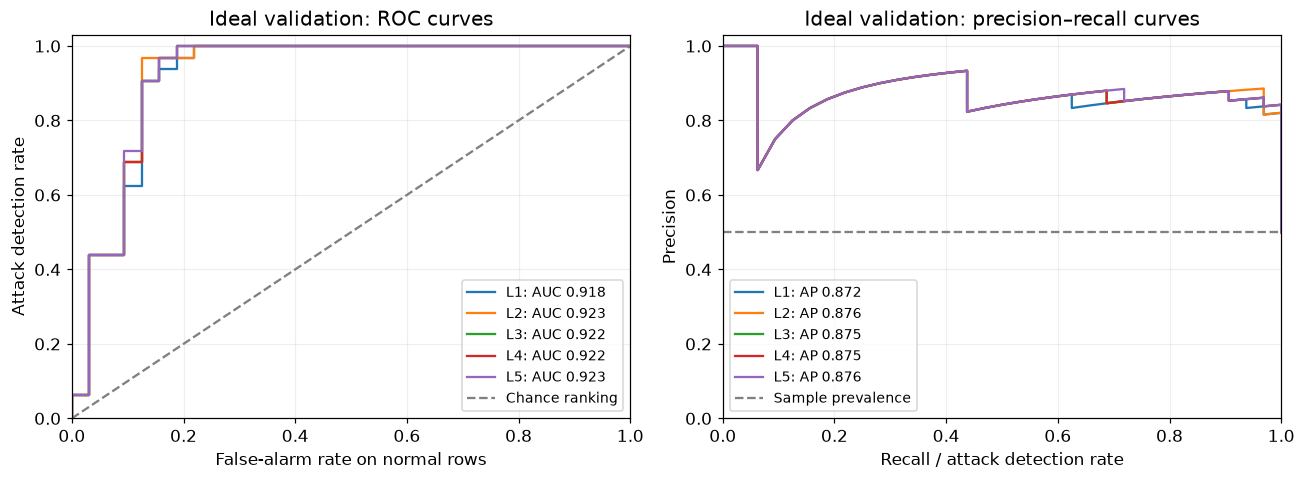

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for L in DEPTHS:
    subset = validation_frame[validation_frame["L"] == L]
    metrics = validation_summary[validation_summary["L"] == L].iloc[0]
    fpr, tpr, _ = roc_curve(subset["true_label"], subset["anomaly_score"])
    precision, recall, _ = precision_recall_curve(subset["true_label"], subset["anomaly_score"])
    axes[0].plot(fpr, tpr, label=f"L{L}: AUC {metrics['roc_auc']:.3f}")
    axes[1].plot(recall, precision, label=f"L{L}: AP {metrics['average_precision']:.3f}")

axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Chance ranking")
axes[1].axhline(y_eval.mean(), linestyle="--", color="gray", label="Sample prevalence")
axes[0].set(xlabel="False-alarm rate on normal rows", ylabel="Attack detection rate",
            title="Ideal validation: ROC curves", xlim=(0, 1), ylim=(0, 1.03))
axes[1].set(xlabel="Recall / attack detection rate", ylabel="Precision",
            title="Ideal validation: precision–recall curves", xlim=(0, 1), ylim=(0, 1.03))
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, "ideal_validation_curves")
plt.show()

## 10. Check sample uncertainty and compare depths fairly

A small validation set can produce an impressive AUC by chance. **Bootstrap resampling** repeatedly draws rows with replacement and recomputes AUC. We sample within each class so every repeat contains normals and attacks.

The 95% interval describes uncertainty from these evaluated samples with the model fixed. It does not include different training runs, compression choices, hardware drift, or measurement-shot uncertainty.

For depth differences we use a **paired** bootstrap: each repeat picks the same sample identities for both depths. This preserves the fact that the models saw identical traffic.

We compare the predeclared L1 reference against each deeper model. A positive difference means L1 ranked these samples better. An interval spanning zero does not clearly distinguish them. These are individual intervals, not a correction for testing several comparisons, and validation was also used to choose a depth.

In [26]:
auc_interval_rows = []
auc_bootstrap_samples = {}

for L in DEPTHS:
    subset = validation_frame[validation_frame["L"] == L]
    interval = evaluation.bootstrap_auc(
        subset["true_label"], subset["anomaly_score"],
        n_bootstrap=BOOTSTRAP_REPEATS, confidence=CONFIDENCE, seed=BOOTSTRAP_SEED,
    )
    auc_interval_rows.append({key: value for key, value in interval.items() if key != "samples"} | {"L": L})
    auc_bootstrap_samples[f"L{L}"] = interval["samples"]

auc_intervals = pd.DataFrame(auc_interval_rows)
validation_report = validation_summary.merge(
    auc_intervals.drop(columns=["roc_auc"]), on="L", validate="one_to_one"
)
depth_comparisons = evaluation.compare_depths(
    validation_frame, region="ideal", reference_depth=1,
    n_bootstrap=BOOTSTRAP_REPEATS, confidence=CONFIDENCE, seed=BOOTSTRAP_SEED,
)

display(validation_report[["L", "roc_auc", "ci_low", "ci_high", "separation"]])
display(depth_comparisons)

if RUN_DIR is not None:
    validation_report.to_csv(RUN_DIR / "ideal_validation_report.csv", index=False)
    depth_comparisons.to_csv(RUN_DIR / "ideal_paired_depth_comparisons.csv", index=False)
    np.savez_compressed(RUN_DIR / "ideal_auc_bootstrap_samples.npz", **auc_bootstrap_samples)

,L,roc_auc,ci_low,ci_high,separation
0,1,0.917969,0.827148,0.983398,0.402129
1,2,0.922852,0.833984,0.987305,0.423817
2,3,0.921875,0.833960,0.986328,0.443550
3,4,0.921875,0.833960,0.986328,0.456397
4,5,0.922852,0.834961,0.986328,0.464081


,region,reference_depth,candidate_depth,reference_auc,candidate_auc,auc_difference,ci_low,ci_high,bootstrap_std,confidence,n_bootstrap
0,ideal,1,2,0.917969,0.922852,-0.004883,-0.015625,0.001953,0.004632,0.95,5000
1,ideal,1,3,0.917969,0.921875,-0.003906,-0.014673,0.003906,0.004924,0.95,5000
2,ideal,1,4,0.917969,0.921875,-0.003906,-0.014673,0.003906,0.004924,0.95,5000
3,ideal,1,5,0.917969,0.922852,-0.004883,-0.017578,0.003906,0.005519,0.95,5000


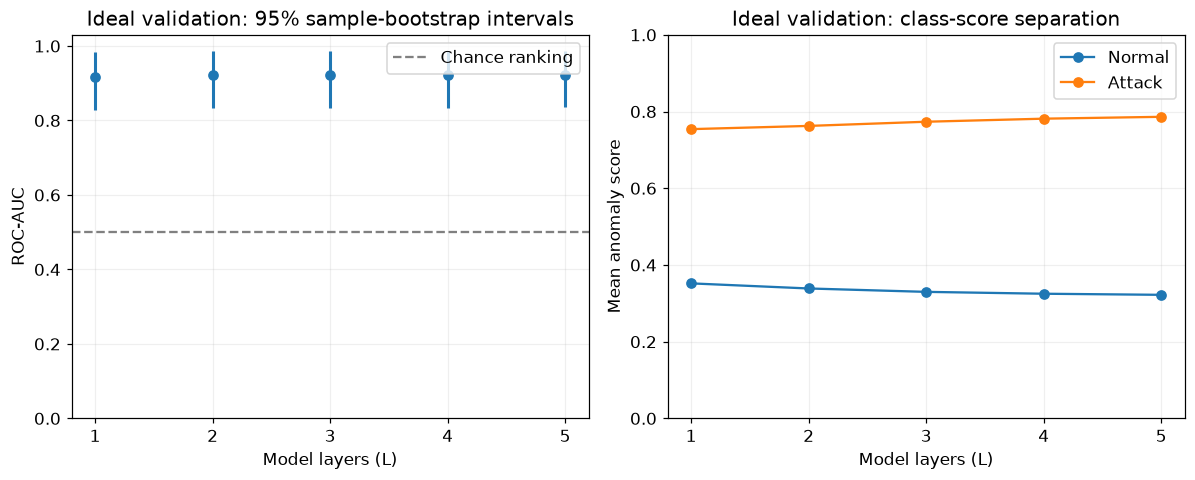

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
report = validation_report.sort_values("L")

# Draw intervals separately from point estimates; a percentile interval need
# not always contain its original point estimate.
axes[0].vlines(report["L"], report["ci_low"], report["ci_high"], color="tab:blue", linewidth=2)
axes[0].scatter(report["L"], report["roc_auc"], color="tab:blue", zorder=3)
axes[0].axhline(0.5, linestyle="--", color="gray", label="Chance ranking")
axes[0].set(xlabel="Model layers (L)", ylabel="ROC-AUC",
            title=f"Ideal validation: {CONFIDENCE:.0%} sample-bootstrap intervals", ylim=(0, 1.03))
axes[0].legend()

axes[1].plot(report["L"], report["normal_mean"], "o-", label="Normal")
axes[1].plot(report["L"], report["anomaly_mean"], "o-", label="Attack")
axes[1].set(xlabel="Model layers (L)", ylabel="Mean anomaly score",
            title="Ideal validation: class-score separation", ylim=(0, 1))
axes[1].legend()
for ax in axes:
    ax.set_xticks(DEPTHS)
    ax.grid(alpha=0.2)
fig.tight_layout()
save_figure(fig, "ideal_depth_comparison")
plt.show()

## 11. Turn ranking scores into a yes/no decision

AUC compares rankings without choosing a cutoff. Actual alerts need a **threshold**: flag a row when its score is at least the threshold.

For the local illustration, choose the highest validation AUC, breaking exact ties toward the shallower model. This is an **ideal-validation choice**, not yet a hardware-adaptive deployment choice.

We choose the cutoff at the 95th percentile of that model's normal validation scores, aiming for roughly 5% false alarms on these normals. This is a policy choice, not a guaranteed future false-alarm rate. With only 32 normal rows, the estimate is coarse; ties can also change the achieved rate.

At that cutoff:
- **Recall / detection rate = TP/(TP+FN):** what fraction of attacks were caught?
- **Precision = TP/(TP+FP):** what fraction of alerts were actually attacks?
- **F1:** the harmonic mean of precision and recall; high F1 needs both to be useful.
- **False-alarm rate = FP/(FP+TN):** what fraction of normals were incorrectly flagged?

TP/TN mean correctly flagged attacks/correctly accepted normals. FP/FN mean false alarms/missed attacks.

The cutoff and depth were chosen on validation data. These threshold metrics are therefore validation estimates, not an untouched test result.

,L,n_samples,n_anomalies,prevalence,normal_mean,anomaly_mean,separation,roc_auc,average_precision,threshold,precision,recall,f1,tn,fp,fn,tp,false_alarm_rate
0,2,64,32,0.5,0.3386,0.762417,0.423817,0.922852,0.876155,0.898442,0.875,0.4375,0.583333,30,2,18,14,0.0625


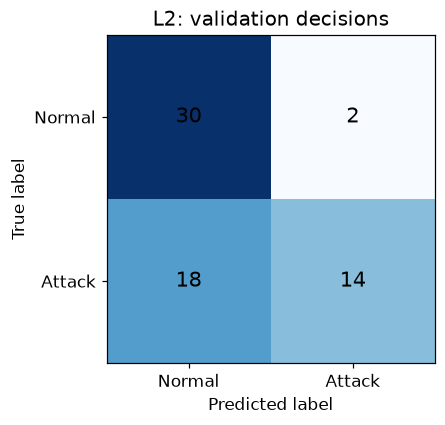

In [28]:
best_ideal_depth = int(
    validation_summary.sort_values(["roc_auc", "L"], ascending=[False, True]).iloc[0]["L"]
)
best_validation = validation_frame[validation_frame["L"] == best_ideal_depth]
normal_validation_scores = best_validation.loc[
    best_validation["true_label"] == 0, "anomaly_score"
]
threshold = float(np.quantile(
    normal_validation_scores, 1.0 - TARGET_VALIDATION_FALSE_ALARM_RATE
))
threshold_metrics = evaluation.detection_metrics(
    best_validation["true_label"], best_validation["anomaly_score"], threshold=threshold
)
threshold_metrics["false_alarm_rate"] = (
    threshold_metrics["fp"] / (threshold_metrics["fp"] + threshold_metrics["tn"])
)

display(pd.DataFrame([{"L": best_ideal_depth, **threshold_metrics}]))
save_json("ideal_validation_threshold.json", {
    "L": best_ideal_depth, "selection": "highest_validation_auc_ties_shallow",
    "threshold_rule": config["threshold"], "metrics": threshold_metrics,
})

fig, ax = plt.subplots(figsize=(5, 4))
matrix = np.array([
    [threshold_metrics["tn"], threshold_metrics["fp"]],
    [threshold_metrics["fn"], threshold_metrics["tp"]],
])
ax.imshow(matrix, cmap="Blues")
for row in range(2):
    for column in range(2):
        ax.text(column, row, str(matrix[row, column]), ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1], labels=["Normal", "Attack"])
ax.set_yticks([0, 1], labels=["Normal", "Attack"])
ax.set(xlabel="Predicted label", ylabel="True label",
       title=f"L{best_ideal_depth}: validation decisions")
fig.tight_layout()
save_figure(fig, "ideal_validation_confusion_matrix")
plt.show()

## 12. Optional final check on held-out test rows

This is disabled by default because we are still reviewing the architecture. Enable it only once the local model and threshold choices are fixed.

The cell uses **one selected depth and the frozen validation threshold**. It does not search for a better threshold or depth on test data.

The test sample is selected uniformly, not forced to 50/50 classes, so it approximately preserves the test partition's class mix. Its precision is more representative of this CSV than balanced-validation precision, but the CSV itself is not necessarily representative of a deployed network.

This is an ideal-simulation test of the locally selected model. It does not certify a different depth or a noisy hardware deployment.

In [29]:
test_frame = None
test_metrics = None

if RUN_HELD_OUT_TEST:
    test_rng = np.random.default_rng(TEST_SEED)
    test_positions = test_rng.choice(
        len(prepared["y_test"]),
        size=min(TEST_SAMPLE_SIZE, len(prepared["y_test"])), replace=False,
    )
    X_test_eval = prepared["X_test_q"][test_positions]
    y_test_eval = prepared["y_test"][test_positions]
    test_sample_ids = prepared["test_idx"][test_positions]
    test_scores = workload.nested_scores(best_ideal_depth, models[best_ideal_depth], X_test_eval)
    test_metadata = [
        {"L": best_ideal_depth, "sample_index": i, "sample_id": int(sample_id),
         "execution": "ideal_statevector", "score": "1-P(0000)"}
        for i, sample_id in enumerate(test_sample_ids)
    ]
    test_frame = evaluation.results_to_frame(test_scores, test_metadata, y_test_eval, region="ideal")
    test_metrics = evaluation.detection_metrics(y_test_eval, test_scores, threshold=threshold)
    display(pd.DataFrame([{"L": best_ideal_depth, **test_metrics}]))
    if RUN_DIR is not None:
        test_frame.to_csv(RUN_DIR / "ideal_held_out_test_scores.csv", index=False)
    save_json("ideal_held_out_test_metrics.json", {"L": best_ideal_depth, **test_metrics})
else:
    print("Held-out test scoring skipped. No test detection result has been generated.")

Held-out test scoring skipped. No test detection result has been generated.


## Pause here: review the complete local experiment

At this point you have a complete route from CSV rows to saved models, validation scores, uncertainty estimates, curves, and an illustrative alert threshold.

Before interpreting success, distinguish these questions:
1. Did the code run and preserve the intended nesting?
2. Did normal training loss improve?
3. Did attacks actually rank above normals on validation?
4. How uncertain are those validation results?
5. Have we evaluated untouched test samples, or only validation?

A successful local run does not establish hardware performance or quantum advantage over a classical detector. This notebook does not yet include a classical baseline.

The next sections are optional. Reading them is safe; the default flags skip all authenticated operations.

## 13. Build the ideal reference for the exact hardware samples

The 32-row hardware set differs from the 64-row local validation set. Comparing hardware AUC on one set with ideal AUC on the other would mix sample differences with hardware effects.

We calculate ideal scores on the **same 32 rows**, using the **same weights at every depth**. This cell is still entirely local.

In [30]:
ideal_hardware_scores = []
ideal_hardware_metadata = []

for L in DEPTHS:
    ideal_hardware_scores.extend(workload.nested_scores(L, models[L], X_hardware_eval))
    ideal_hardware_metadata.extend({
        "L": L, "sample_index": i, "sample_id": int(sample_id),
        "execution": "ideal_statevector", "score": "1-P(0000)",
    } for i, sample_id in enumerate(hardware_sample_ids))

ideal_hardware_frame = evaluation.results_to_frame(
    ideal_hardware_scores, ideal_hardware_metadata, y_hardware_eval, region="ideal"
)
ideal_hardware_summary = evaluation.summarize_results(ideal_hardware_frame)
display(ideal_hardware_summary[["L", "roc_auc", "separation"]])

if RUN_DIR is not None:
    ideal_hardware_frame.to_csv(RUN_DIR / "ideal_hardware_sample_scores.csv", index=False)
    ideal_hardware_summary.to_csv(RUN_DIR / "ideal_hardware_sample_metrics.csv", index=False)

,L,roc_auc,separation
0,1,0.636719,0.128606
1,2,0.636719,0.138930
2,3,0.644531,0.152421
3,4,0.644531,0.161678
4,5,0.644531,0.166831


In [41]:
# Enable these only when intentionally starting new hardware work.
# Both remain off in the published notebook.
CONNECT_TO_IBM = False
SUBMIT_QPU_JOBS = False


## 14. Optional IBM connection and compilation

**CONNECT_TO_IBM=False:** this cell skips connection and credential loading.

When you deliberately enable it, backend.connect_backend loads the token from the external **~/.qff26/.env** through python-dotenv. The notebook never prints or saves the token.

A **physical region** is the ordered set of four actual chip qubits used for our four logical qubits. Compilation translates the circuit into the backend's supported gates and forces that layout. We compile parameterized templates once per depth and region, then bind data and weights without recompiling every sample.

Parameterization means additional zero-initialized layers can still leave physical gate costs in the compiled template. Ideal nesting is not a promise of equal hardware noise.

Connecting and compiling do not submit a QPU job. The next section has its own submission flag.

In [42]:
ibm_service = None
ibm_backend = None
hardware_templates = {}
hardware_resources = {}
hardware_backend_metadata = None
hardware_frames = {}
hardware_submissions = {}

if CONNECT_TO_IBM:
    ibm_service, ibm_backend = backend.connect_backend(BACKEND_NAME)
    hardware_backend_metadata = backend.get_backend_metadata(ibm_backend)
    save_json("backend_metadata.json", hardware_backend_metadata)

    resource_rows = []
    for region_name, physical_qubits in HARDWARE_REGIONS.items():
        templates = workload.prepare_final_templates(
            ibm_backend, physical_qubits, depths=DEPTHS, seed_transpiler=SPLIT_SEED
        )
        hardware_templates[region_name] = templates
        resources = controller.model_resources(templates, ibm_backend)
        hardware_resources[region_name] = resources
        for L, resource in resources.items():
            resource_rows.append({"region": region_name, "L": L, **resource})

    display(pd.DataFrame(resource_rows)[["region", "L", "physical_qubits",
                                        "transpiled_depth", "two_qubit_gates"]])
    save_json("compiled_model_resources.json", hardware_resources)
else:
    print("IBM connection skipped. No credentials loaded and no backend contacted.")

qiskit_runtime_service._discover_account:WARNING:2026-10-07 23:16:12,024: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-10-07 23:16:19,766: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-07 23:16:19,767: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


,region,L,physical_qubits,transpiled_depth,two_qubit_gates
0,0123,1,"[0, 1, 2, 3]",44,6
1,0123,2,"[0, 1, 2, 3]",83,12
2,0123,3,"[0, 1, 2, 3]",122,18
3,0123,4,"[0, 1, 2, 3]",161,24
4,0123,5,"[0, 1, 2, 3]",200,30
5,6789,1,"[6, 7, 8, 9]",44,6
6,6789,2,"[6, 7, 8, 9]",83,12
7,6789,3,"[6, 7, 8, 9]",122,18
8,6789,4,"[6, 7, 8, 9]",161,24
9,6789,5,"[6, 7, 8, 9]",200,30


## 15. Optional hardware evaluation: frozen models, one job per region

**SUBMIT_QPU_JOBS=False:** no circuits are submitted.

If you enable both hardware flags, each region gets one batch containing every selected depth and sample. With the default five depths, 32 samples, and 256 shots, that is **160 circuits and 40,960 shots per region**.

A **shot** is one execution and measurement of a circuit. We measure all four bits and estimate the score as **1 − count(0000)/total shots**.

This is a depth-comparison experiment, so it measures all configured depths. The controller's deployment restrictions are applied afterward; measuring a model here is not a claim that the controller considers it suitable for deployment.

The job ID and sample manifest are saved before waiting for results. A job may remain queued or fail. A saved ID is evidence of submission, not evidence of completed measurements.

Rerunning a submission can create a new paid hardware job. Within this kernel, the guard below refuses to resubmit a region already attempted. If waiting fails, use the saved job ID with execution.retrieve_job/retrieve_results to recover that job rather than submitting another. Re-executing the connection cell resets this in-memory guard, so do not use it as a recovery shortcut.

In [43]:
if SUBMIT_QPU_JOBS:
    if ibm_backend is None or not hardware_templates:
        raise RuntimeError("Run the enabled connection/compilation cell first.")
    if RUN_DIR is None:
        raise RuntimeError("A saved run directory is required before submitting jobs.")

    sampler = execution.create_sampler(ibm_backend)
    for region_name, templates in hardware_templates.items():
        if region_name in hardware_submissions:
            raise RuntimeError(
                f"{region_name} already submitted as {hardware_submissions[region_name]}; recover that job."
            )

        def record_submission(job, metadata, region=region_name):
            job_id = job.job_id()
            hardware_submissions[region] = job_id
            execution.save_submission_record(
                RUN_DIR / f"job_{region}_{job_id}.json", job_id,
                shots=SHOTS, circuit_metadata=metadata,
                config={"backend": BACKEND_NAME, "region": region,
                        "physical_qubits": HARDWARE_REGIONS[region],
                        "dataset_sha256": dataset_sha256,
                        "architecture": config["architecture"],
                        "sample_ids": hardware_sample_ids.tolist()},
            )
            print(f"{region}: submitted job {job_id}")

        scores, metadata = workload.evaluate_final_region(
            region_name, templates, X_hardware_eval, models, sampler=sampler,
            shots=SHOTS, sample_ids=hardware_sample_ids, on_submitted=record_submission,
        )
        frame = evaluation.results_to_frame(scores, metadata, y_hardware_eval)
        hardware_frames[region_name] = frame
        frame.to_csv(RUN_DIR / f"hardware_{region_name}_scores.csv", index=False)
        save_json(f"hardware_{region_name}_observations.json", metadata)
        print(f"{region_name}: completed results saved.")
else:
    print("QPU submission skipped.")

0123: submitted job db3gm1svf2bc73ct47o0
0123: completed results saved.
6789: submitted job db3gm7klf4us73c18k20
6789: completed results saved.


## 16. Compare hardware with the matching ideal reference

Only completed results are summarized. AUC loss means **ideal AUC minus hardware AUC** on the same traffic rows. It can be negative because finite samples and shots can favor hardware on a particular run; it is not necessarily a monotonic noise measurement.

We can also pair the two physical regions by sample_id. Jobs run at different times, so a region comparison can mix regional differences with hardware drift. The sample-bootstrap interval does not measure that drift.

The figures and tables in this section are distinct from the local 64-row validation report. They use the 32-row hardware comparison set.

,region,L,roc_auc,ideal_roc_auc,auc_loss,separation_loss
0,0123,1,0.628906,0.636719,0.007812,0.015081
1,0123,2,0.650391,0.636719,-0.013672,0.015639
2,0123,3,0.644531,0.644531,0.000000,0.005693
3,0123,4,0.656250,0.644531,-0.011719,0.012753
4,0123,5,0.650391,0.644531,-0.005859,0.017173
5,6789,1,0.636719,0.636719,0.000000,0.005559
6,6789,2,0.656250,0.636719,-0.019531,0.004408
7,6789,3,0.650391,0.644531,-0.005859,-0.002120
8,6789,4,0.666016,0.644531,-0.021484,-0.006290
9,6789,5,0.664062,0.644531,-0.019531,0.009361


,L,reference_region,candidate_region,reference_auc,candidate_auc,auc_difference,ci_low,ci_high,bootstrap_std,confidence,n_bootstrap
0,1,0123,6789,0.628906,0.636719,-0.007812,-0.058594,0.039062,0.023772,0.95,5000
1,2,0123,6789,0.650391,0.656250,-0.005859,-0.042969,0.023438,0.015339,0.95,5000
2,3,0123,6789,0.644531,0.650391,-0.005859,-0.058594,0.031250,0.022017,0.95,5000
3,4,0123,6789,0.656250,0.666016,-0.009766,-0.039062,0.009766,0.012512,0.95,5000
4,5,0123,6789,0.650391,0.664062,-0.013672,-0.058594,0.023438,0.019869,0.95,5000


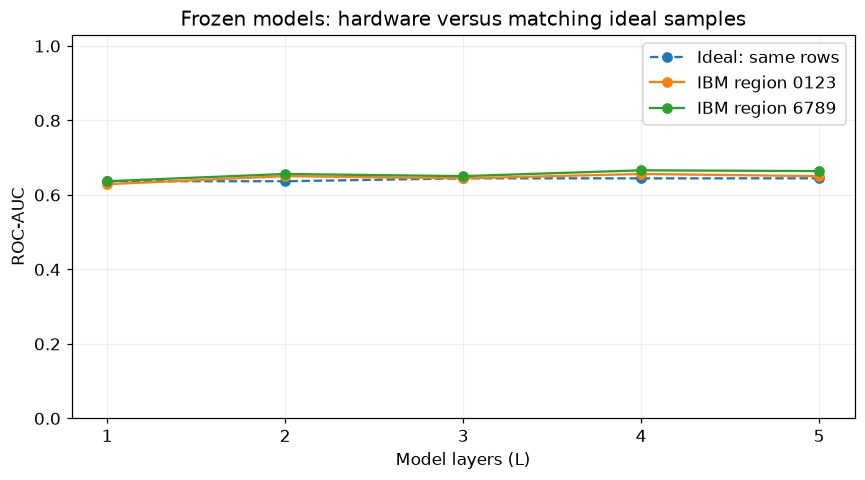

In [44]:
hardware_summary = None
hardware_comparison = None
region_comparisons = None

if hardware_frames:
    hardware_frame = pd.concat(hardware_frames.values(), ignore_index=True)
    hardware_summary = evaluation.summarize_results(hardware_frame)
    ideal_reference = ideal_hardware_summary[["L", "roc_auc", "separation"]].rename(
        columns={"roc_auc": "ideal_roc_auc", "separation": "ideal_separation"}
    )
    hardware_comparison = hardware_summary.merge(ideal_reference, on="L", validate="many_to_one")
    hardware_comparison["auc_loss"] = (
        hardware_comparison["ideal_roc_auc"] - hardware_comparison["roc_auc"]
    )
    hardware_comparison["separation_loss"] = (
        hardware_comparison["ideal_separation"] - hardware_comparison["separation"]
    )
    display(hardware_comparison[["region", "L", "roc_auc", "ideal_roc_auc",
                                 "auc_loss", "separation_loss"]])

    if len(hardware_frames) > 1:
        reference_region = next(iter(hardware_frames))
        region_comparisons = pd.concat([
            evaluation.compare_regions(
                hardware_frame, depth=L, reference_region=reference_region,
                n_bootstrap=BOOTSTRAP_REPEATS, confidence=CONFIDENCE, seed=BOOTSTRAP_SEED,
            )
            for L in DEPTHS
        ], ignore_index=True)
        display(region_comparisons)
        if RUN_DIR is not None:
            region_comparisons.to_csv(RUN_DIR / "paired_hardware_region_comparisons.csv", index=False)

    if RUN_DIR is not None:
        hardware_summary.to_csv(RUN_DIR / "hardware_metrics.csv", index=False)
        hardware_comparison.to_csv(RUN_DIR / "hardware_vs_matching_ideal.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(ideal_reference["L"], ideal_reference["ideal_roc_auc"], "o--", label="Ideal: same rows")
    for region_name, subset in hardware_summary.groupby("region", sort=False):
        ax.plot(subset["L"], subset["roc_auc"], "o-", label=f"IBM region {region_name}")
    ax.set(xlabel="Model layers (L)", ylabel="ROC-AUC",
           title="Frozen models: hardware versus matching ideal samples", ylim=(0, 1.03))
    ax.set_xticks(DEPTHS)
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    save_figure(fig, "hardware_vs_matching_ideal")
    plt.show()
else:
    print("No completed hardware results to compare.")

In [45]:
MRB_RESULTS_PATH = REPO_ROOT / "results" / "mrb_20261008T031414Z_5f6bd2" / "mrb_results.json"
MAX_POLARIZATION_LOSS = 0.10


## 17. Optional hardware-adaptive depth decision

MRB (**Mirror Randomized Benchmarking**) is a separate experiment in **hardware_probe.ipynb**. It runs randomized circuits with mirrored operations and checks their known ideal outcomes. It measures a region's hardware behavior; it does not classify network traffic.

**Polarization** is the benchmark's normalized measure of retained signal. The fitted **p** describes how much of that signal remains per additional benchmark depth unit: near 1 means slow decay; smaller values mean faster decay. The controller budgets the signal loss relative to the fitted depth-zero baseline.

To use an existing MRB result here, set MRB_RESULTS_PATH to a JSON record from **one fresh probe run** on the same backend, with this shape:

    {"backend": "ibm_quebec", "recorded_at_utc": "...",
     "records": [{"region": "0123", "physical_qubits": [0,1,2,3],
                  "depth": 8, "instance": 0, "two_qubit_gates": ...,
                  "polarization": ...}, ...]}

This wrapper records the backend and time. The records themselves come from probes.process_mrb_results. Do not mix older probe runs. Check the printed timestamp; this notebook does not claim a universal freshness interval.

Choose MAX_POLARIZATION_LOSS explicitly. It budgets the proxy **1−p^(equivalent MRB depth)**, not classification errors:
- Fit the growth in compiled MRB two-qubit gate counts.
- Divide a QML model's compiled gate count by that growth rate to get equivalent MRB depth.
- Constrain estimated relative polarization loss; reject extrapolation beyond the measured depths.
- Among allowed depths, select the best validation AUC. If none pass, select no depth.

This gate-count mapping is a modeling assumption. It does not capture every difference between MRB and QML circuits. It excludes the fitted depth-zero offset from the loss budget and does not establish an absolute hardware failure probability.

The decision below uses the completed hardware validation metrics for that region. It uses the MRB point estimate; a conservative lower bound from the probe bootstrap can be supplied to controller.constrain_depths when available. Better hardware expands the allowed choices; it does not automatically make deeper models better.

In [46]:
controller_results = {}

if MRB_RESULTS_PATH is None:
    print("Controller skipped: no fresh MRB result file supplied.")
elif not hardware_frames:
    print("Controller skipped: need compiled models and completed hardware validation.")
else:
    if MAX_POLARIZATION_LOSS is None:
        raise ValueError("Choose MAX_POLARIZATION_LOSS explicitly before applying the controller.")
    mrb_path = Path(MRB_RESULTS_PATH).expanduser()
    if not mrb_path.is_absolute():
        mrb_path = REPO_ROOT / mrb_path
    with mrb_path.open("r", encoding="utf-8") as handle:
        mrb_run = json.load(handle)
    if mrb_run["backend"] != hardware_backend_metadata["backend"]:
        raise ValueError("MRB and QML backend names differ.")
    print("MRB measurement record timestamp:", mrb_run["recorded_at_utc"])
    mrb_records = mrb_run["records"]

    for region_name in hardware_frames:
        measured_depths = sorted({
            row["depth"] for row in mrb_records if row["region"] == region_name
        })
        fit = probes.fit_mrb_region(mrb_records, region_name, measured_depths)
        calibration = controller.calibrate_mrb_cost(mrb_records, region_name)
        constraints = controller.constrain_depths(
            fit, calibration, hardware_resources[region_name],
            max_polarization_loss=MAX_POLARIZATION_LOSS,
        )
        decision = controller.select_depth(constraints, hardware_summary)
        controller_results[region_name] = {
            "mrb_source": str(mrb_path), "mrb_timestamp": mrb_run["recorded_at_utc"],
            "constraints": constraints, "decision": decision,
        }
        display(pd.DataFrame(constraints["depth_decisions"]))
        print(region_name, "deployment choice:", decision["selected_depth"])

    save_json("controller_decisions.json", controller_results)

MRB measurement record timestamp: 2026-10-08T03:14:16.058170+00:00


,L,two_qubit_gates,equivalent_mrb_depth,predicted_polarization_loss,extrapolated,allowed,reason
0,1,6,5.818182,0.053441,False,True,within_budget
1,2,12,11.636364,0.104026,False,False,over_budget
2,3,18,17.454545,0.151907,False,False,over_budget
3,4,24,23.272727,0.197230,False,False,over_budget
4,5,30,29.090909,0.240131,False,False,over_budget


0123 deployment choice: 1


,L,two_qubit_gates,equivalent_mrb_depth,predicted_polarization_loss,extrapolated,allowed,reason
0,1,6,5.818182,0.379142,False,False,over_budget
1,2,12,11.636364,0.614535,False,False,over_budget
2,3,18,17.454545,0.760681,False,False,over_budget
3,4,24,23.272727,0.851417,False,False,over_budget
4,5,30,29.090909,0.907751,False,False,over_budget


6789 deployment choice: None


## 18. What depends on what?

The notebook's variables are deliberate handoffs between stages:

| Variable | Created by | Used by |
|---|---|---|
| X_raw, y | Loading | Data preparation |
| prepared | Splitting and fitted preprocessing | Sampling, saving, optional test |
| X_local_train | Normal-only sampling | Local training |
| X_eval, y_eval, validation_sample_ids | Fixed balanced validation selection | All local depth comparisons |
| models, histories | Training or checkpoint loading | Scoring, figures, hardware |
| validation_frame, validation_summary | Frozen-model scoring | Bootstrap, curves, local depth/cutoff selection |
| best_ideal_depth, threshold | Validation selection | Optional local held-out test |
| X_hardware_eval, y_hardware_eval, hardware_sample_ids | Separate fixed validation selection | Matching ideal reference and both QPU regions |
| hardware_templates, hardware_resources | Optional connection and compilation | Hardware scoring and controller cost mapping |
| hardware_frames, hardware_summary | Completed QPU results | Region comparison and controller selection |

Changing preprocessing requires reconsidering the weights and all downstream scores. Changing weights requires recomputing scores and metrics. Changing an evaluated sample set requires recomputing matching references and paired comparisons.

A partial models_progress.npz preserves completed depths, but it is not a completed L1–L5 checkpoint. models.npz is written only after all model shapes and prefixes pass their checks.

## 19. What this run generated, and what you can claim

With saving enabled, the run directory can contain:

| Artifact | Purpose |
|---|---|
| config.json | Dataset fingerprint, settings, software versions, architecture |
| preprocessor.joblib | Fitted category encoding, scaling, and SVD |
| prepared_samples.npz | Exact split/sample identities and quantum input arrays |
| models.npz, training histories | Completed weights and checked training losses |
| ideal_validation_*.csv | Per-sample scores, metrics, and sample uncertainty |
| ideal_paired_depth_comparisons.csv | Paired comparisons against L1 |
| ideal_validation_threshold.json | Locally chosen model, alert cutoff, and validation metrics |
| ideal_hardware_sample_*.csv | Ideal reference on exactly the QPU sample set |
| job_*.json, hardware_*.csv / observations | Submitted job identities and completed measurement results, if enabled |
| controller_decisions.json | Hardware constraints and the selected allowed model, if fresh probes were supplied |
| figures/*.png and *.pdf | Labeled figures for the report/presentation |

Only files corresponding to stages actually run will exist.

Keep **training improvement**, **validation detection performance**, **held-out test evidence**, and **hardware-adaptive deployment** separate in the presentation. An empty/skipped section is not a result, and a submitted IBM job is not a completed experiment.

In [47]:
run_status = {
    "run_name": run_name,
    "analysis_completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "execution_mode": "ideal_local_plus_explicit_optional_hardware",
    "model_depths_available": sorted(models),
    "local_validation_samples": len(y_eval),
    "ideal_selected_depth": best_ideal_depth,
    "held_out_test_scored": test_metrics is not None,
    "hardware_jobs_submitted": hardware_submissions,
    "hardware_regions_completed": list(hardware_frames),
    "controller_regions_evaluated": list(controller_results),
}
save_json("run_status.json", run_status)
display(pd.DataFrame([{
    "local validation rows": len(y_eval),
    "ideal validation choice": f"L{best_ideal_depth}",
    "test scored": test_metrics is not None,
    "completed QPU regions": ", ".join(hardware_frames) or "none",
    "controller decisions": len(controller_results),
}]))
print("Run directory:", RUN_DIR if RUN_DIR is not None else "not saved")

,local validation rows,ideal validation choice,test scored,completed QPU regions,controller decisions
0,64,L2,False,"0123, 6789",2


Run directory: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\unsw_nested_20261008T025411Z_a86f5fa1


## Where the behavior came from

These references use **zero-based cell numbers** in teammate_latest.ipynb.

| Behavior | Latest notebook source |
|---|---|
| UNSW loading, normal-only preprocessing, four-component SVD, angles | C126–C130 |
| 64-row local validation, fixed 128-row training, 32-row hardware sample set | C138, C146, C171 |
| Mandatory encoding once and 11-weight Ry/Rz/CRX nested layers | C151 |
| New-layer-only SPSA and progressive initialization | C160, C166 |
| Global score 1−P(0000) | C164 |
| All-qubit hardware templates and per-region batch scoring | C172, C174 |
| Same-sample ideal/hardware comparison idea | C177–C180 |

The readable orchestration, experiment records, checkpoint callbacks, local uncertainty reports, paired region analysis, figures, threshold/test illustration, and controller connection are new integration around the extracted modules.

The historical and teammate notebooks remain untouched. This notebook uses the latest architecture, not the superseded per-layer data re-uploading or input-strength-gated experiments.

In [48]:
print(RUN_DIR)
print("Saved models:", RUN_DIR is not None and (RUN_DIR / "models.npz").is_file())
print({L: len(theta) for L, theta in models.items()})

c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\unsw_nested_20261008T025411Z_a86f5fa1
Saved models: True
{1: 11, 2: 22, 3: 33, 4: 44, 5: 55}


In [ ]:
if hardware_summary is not None:
    display(hardware_summary[["region", "L", "roc_auc", "separation"]])
else:
    print("No hardware evaluation in this run. See the recorded results folder for saved measurements.")
print("Results folder:", RUN_DIR)
